In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"C:\Users\DELL\Downloads\diabetes.csv")

print(df.head())

   Number of times pregnant  Glucose  BloodPressure  SkinThickness  Insulin  \
0                         6      148             72             35        0   
1                         1       85             66             29        0   
2                         8      183             64              0        0   
3                         1       89             66             23       94   
4                         0      137             40             35      168   

    BMI  Diabetes pedigree function  Age  Class  
0  33.6                       0.627   50      1  
1  26.6                       0.351   31      0  
2  23.3                       0.672   32      1  
3  28.1                       0.167   21      0  
4  43.1                       2.288   33      1  


In [2]:
# Get information about data types and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Number of times pregnant    768 non-null    int64  
 1   Glucose                     768 non-null    int64  
 2   BloodPressure               768 non-null    int64  
 3   SkinThickness               768 non-null    int64  
 4   Insulin                     768 non-null    int64  
 5   BMI                         768 non-null    float64
 6   Diabetes pedigree function  768 non-null    float64
 7   Age                         768 non-null    int64  
 8   Class                       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [3]:
df[['Glucose', 'BloodPressure', 'SkinThickness' , 'Insulin',  'BMI']].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,20.536458,79.799479,31.992578
std,31.972618,19.355807,15.952218,115.244002,7.884160
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000
50%,117.000000,72.000000,23.000000,30.500000,32.000000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


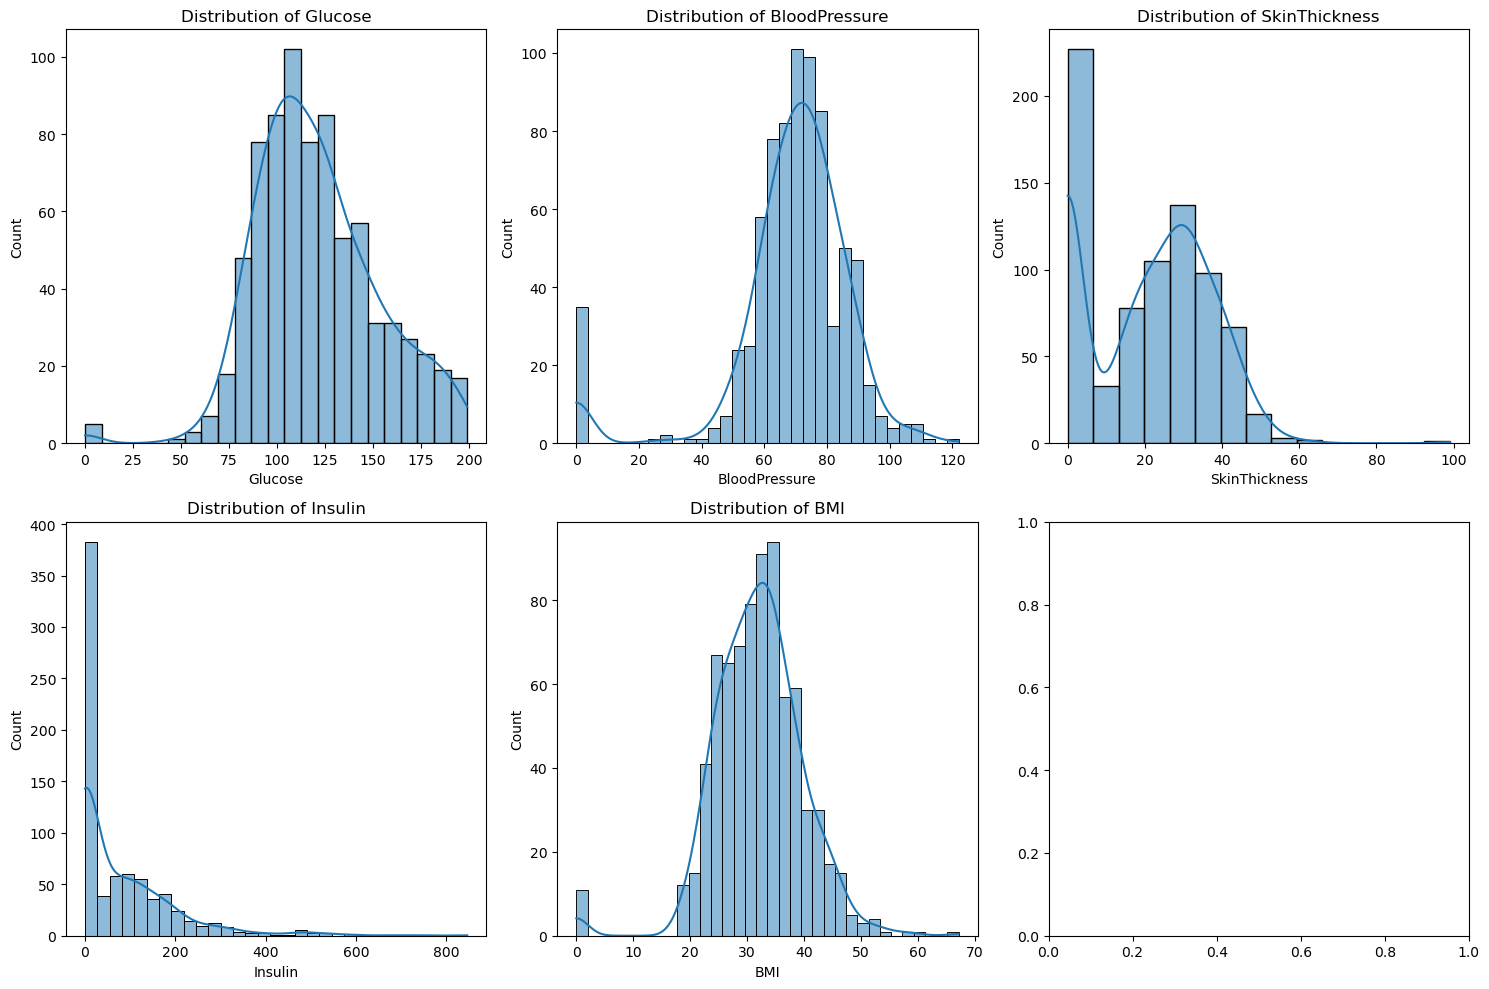

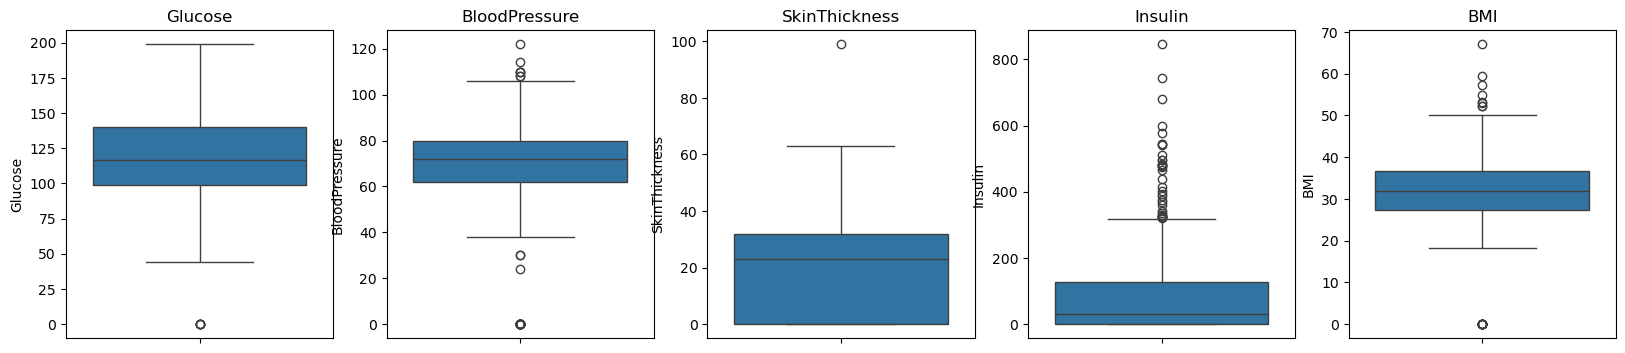

In [4]:
#visualise distribution


cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.show()


In [5]:
# Count zeros in  in Variables That Shouldn’t be Zero
for col in cols:
    zero_count = (df[col] == 0).sum()
    print(f'{col}: {zero_count} zeros')

Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [6]:
# Handling Anomalies
#a.)Replace zeros with NaN
for col in cols:
    df[col] = df[col].replace(0, np.nan)
    
#b.)Impute missing values with the median value of each column
for col in cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'Imputed missing values in {col} with median: {median_val}')

Imputed missing values in Glucose with median: 117.0
Imputed missing values in BloodPressure with median: 72.0
Imputed missing values in SkinThickness with median: 29.0
Imputed missing values in Insulin with median: 125.0
Imputed missing values in BMI with median: 32.3


C:\Users\DELL\AppData\Local\Temp\ipykernel_34380\1401710147.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [8]:
#Using LinearRegression to predict missing values 
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. In the cell above, I've already replaced zeros with NaN and imputed them with medians for predictors. 
#So there are no missing values in any predictor column
predictors = ['Number of times pregnant', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Diabetes pedigree function', 'Age']

#2. Regression imputation

df_reg = df.copy()

# b. To simulate missing data, some Insulin values are removed 
np.random.seed(42)
missing_idx = np.random.choice(df_reg.index, size=50, replace=False)
df_reg.loc[missing_idx, 'Insulin'] = np.nan

#c.  Random imputation with median is passed to the predictor variables to ensure they have no missing values.
for col in predictors:
    df_reg[col] = df_reg[col].fillna(df_reg[col].median())

#d. splitting the data into training and testing categories
# 1. Rows where Insulin is not missing (for training)
# 2. Rows where Insulin is missing (to predict)
train_data = df_reg[df_reg['Insulin'].notnull()]
predict_data = df_reg[df_reg['Insulin'].isnull()]

#e. Training a linear regression model on complete cases for Insulin
model = LinearRegression()
model.fit(train_data[predictors], train_data['Insulin'])

# f. Use the model to predict missing Insulin values
predicted_values = model.predict(predict_data[predictors])

#g. Fill in the missing values with the predicted values
df_reg.loc[df_reg['Insulin'].isnull(), 'Insulin'] = predicted_values

In [9]:
#random imputation
import numpy as np
import pandas as pd

random_imputed = df.copy()

np.random.seed(42)
missing_idx = np.random.choice(random_imputed.index, size=50, replace=False)
random_imputed.loc[missing_idx, 'Insulin'] = np.nan

random_imputed['Insulin_random'] = random_imputed['Insulin']

observed_insulin = random_imputed['Insulin_random'].dropna()

n_missing = random_imputed['Insulin_random'].isnull().sum()
random_values = np.random.choice(observed_insulin, size=n_missing, replace=True)

random_imputed.loc[random_imputed['Insulin_random'].isnull(), 'Insulin_random'] = random_values

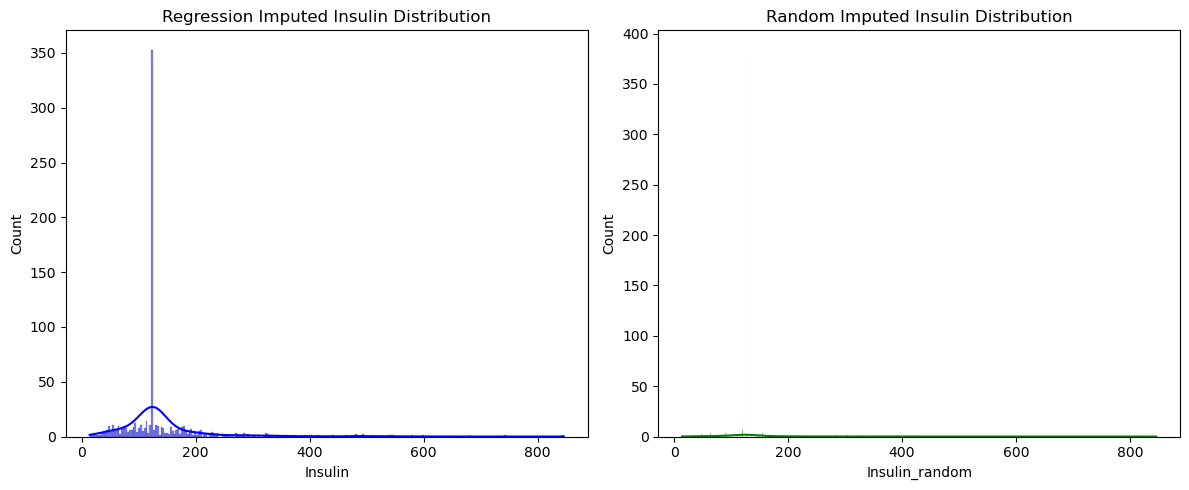

In [10]:
# comapring regression imputation vs random imputation using histogram

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_reg['Insulin'], kde=True, color='blue')
plt.title('Regression Imputed Insulin Distribution')

plt.subplot(1,2,2)
sns.histplot(random_imputed['Insulin_random'], kde=True, color='green')
plt.title('Random Imputed Insulin Distribution')

plt.tight_layout()
plt.show()

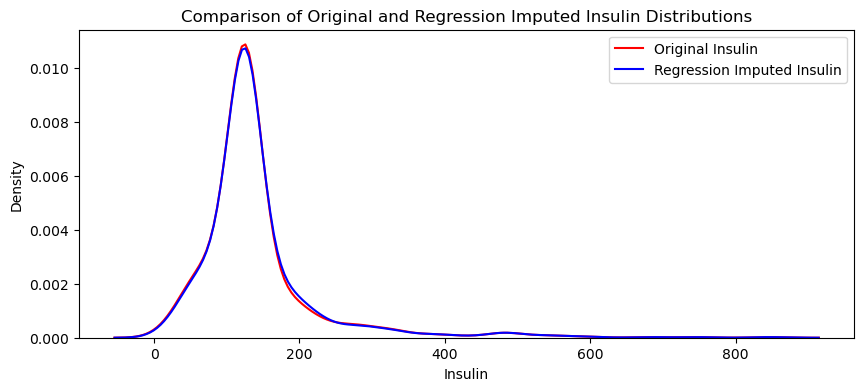

In [11]:
# overlay the distributions of Original and Regression Imputed Insulin Distributions
plt.figure(figsize=(10,4))
sns.kdeplot(df['Insulin'].dropna(), label='Original Insulin', color='red')
sns.kdeplot(df_reg['Insulin'], label='Regression Imputed Insulin', color='blue')
plt.title('Comparison of Original and Regression Imputed Insulin Distributions')
plt.xlabel('Insulin')
plt.ylabel('Density')
plt.legend()
plt.show()

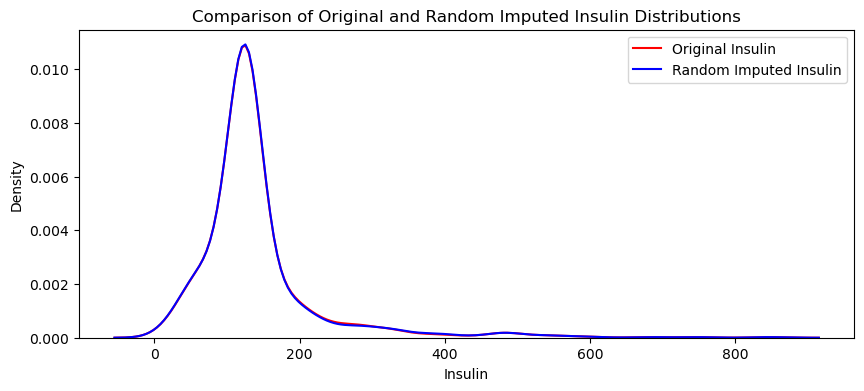

In [12]:
# overlay the distributions of Original and Random Imputed Insulin Distributions
plt.figure(figsize=(10,4))
sns.kdeplot(df['Insulin'].dropna(), label='Original Insulin', color='red')
sns.kdeplot(random_imputed['Insulin_random'], label='Random Imputed Insulin', color='blue')
plt.title('Comparison of Original and Random Imputed Insulin Distributions')
plt.xlabel('Insulin')
plt.ylabel('Density')
plt.legend()
plt.show()